In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
fraud_data = pd.read_csv("fraud_detection.csv")

print("Dataset loaded successfully!")
print(fraud_data.head())
print("\nShape:", fraud_data.shape)

Dataset loaded successfully!
   TransactionAmount  TransactionFrequency  International  AccountAge  Fraud
0                100                     2              0          60      0
1               2500                    15              1           5      1
2                 50                     1              0         120      0
3               5000                    20              1           3      1
4                120                     3              0          80      0

Shape: (15, 5)


In [3]:
X = fraud_data.drop("Fraud", axis=1)
y = fraud_data["Fraud"]

print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['TransactionAmount', 'TransactionFrequency', 'International', 'AccountAge']
Target: Fraud


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 10
Testing samples: 5


In [5]:
# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_model.fit(X_train, y_train)


# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

rf_model.fit(X_train, y_train)


# XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("All three models trained successfully!")

All three models trained successfully!


In [6]:
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

dt_prob = dt_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [7]:
models = {
    "Decision Tree": (dt_pred, dt_prob),
    "Random Forest": (rf_pred, rf_prob),
    "XGBoost": (xgb_pred, xgb_prob)
}

results = []

for name, (pred, prob) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

metrics_df = pd.DataFrame(results)

print(metrics_df)

           Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Decision Tree       1.0        1.0     1.0       1.0      1.0
1  Random Forest       1.0        1.0     1.0       1.0      1.0
2        XGBoost       1.0        1.0     1.0       1.0      1.0


In [8]:
metrics_df.to_csv(
    "classification_metrics_comparison.csv",
    index=False
)

print("Metrics comparison saved successfully!")

Metrics comparison saved successfully!


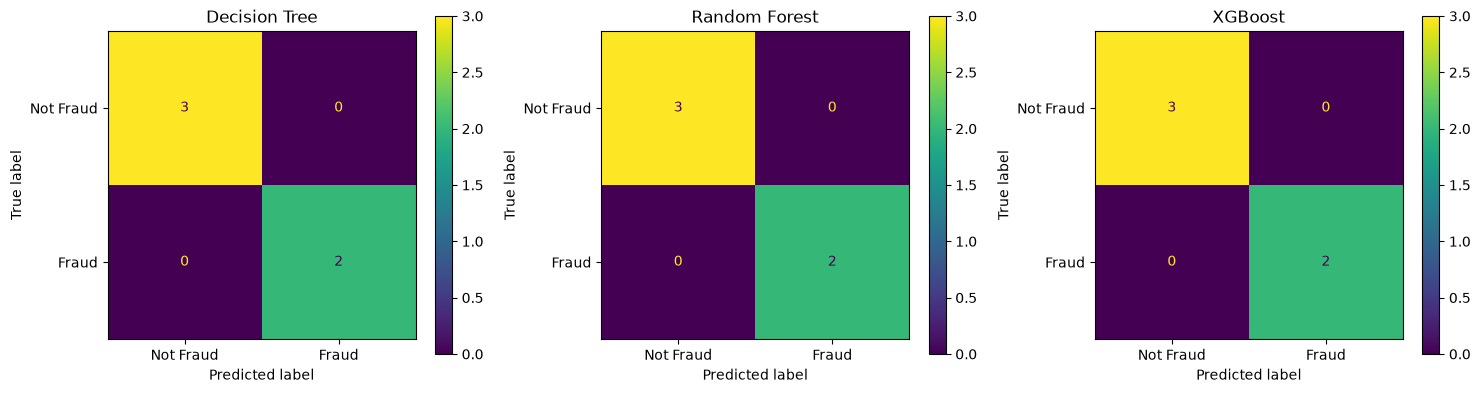

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_predictions = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for ax, (name, pred) in zip(axes, models_predictions.items()):
    cm = confusion_matrix(y_test, pred)
    
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Fraud", "Fraud"]
    ).plot(ax=ax)

    ax.set_title(name)

plt.tight_layout()
plt.show()

In [10]:
fig.savefig(
    "confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

print("Confusion matrices saved successfully!")

Confusion matrices saved successfully!


## Understanding Confusion Matrices

A confusion matrix contains four outcomes:

- True Positive (TP): Fraud correctly identified as fraud.
- True Negative (TN): Legitimate transaction correctly identified as not fraud.
- False Positive (FP): Legitimate transaction incorrectly flagged as fraud.
- False Negative (FN): Fraud incorrectly classified as legitimate.

In fraud detection, false negatives can be particularly important because they represent fraudulent transactions that the system failed to detect.

Therefore, accuracy alone may not provide a complete picture of model performance.

## When Accuracy Becomes Misleading

Accuracy can be misleading when the dataset is highly imbalanced.

For example, if 99% of transactions are legitimate and only 1% are fraudulent, a model that predicts every transaction as legitimate could achieve 99% accuracy while detecting zero fraud.

Therefore, fraud detection should also consider:

- Precision — How many transactions predicted as fraud were actually fraud?
- Recall — How many actual fraud cases were detected?
- F1-Score — Balance between precision and recall.
- ROC-AUC — Measures how well the model separates the two classes.

For fraud detection, recall can be especially important because missing fraudulent transactions can have significant consequences.

## Model Strengths and Weaknesses

### Decision Tree
**Strengths:**
- Easy to understand and visualize
- Simple decision rules
- Fast to train

**Weaknesses:**
- Can overfit easily
- Less robust than ensemble methods

### Random Forest
**Strengths:**
- Combines multiple Decision Trees
- More robust than a single tree
- Can reduce overfitting

**Weaknesses:**
- More computationally expensive
- Less interpretable than one Decision Tree

### XGBoost
**Strengths:**
- Powerful predictive performance
- Handles complex relationships
- Supports regularization

**Weaknesses:**
- Requires parameter tuning
- More complex to interpret
- Can overfit with inappropriate settings

## Conclusion

In Day 20, I evaluated Decision Tree, Random Forest, and XGBoost using multiple performance metrics.

I compared accuracy, precision, recall, F1-score, and ROC-AUC and generated confusion matrices for each model.

This analysis showed why relying only on accuracy can be misleading, especially for imbalanced problems such as fraud detection.

The evaluation process helps select a model based on the actual business objective rather than a single performance metric.